# SAM to Surface Plane

This notebook bridges camera-space target selection to local force probing on the robot.

Workflow:
- Capture an aligned RGB and depth frame from the RealSense.
- Select the metal plate or sheet-metal part either by manual ROI or by a SAM3 prompt hook.
- Convert the mask centroid into a robot-base target using the saved camera intrinsics and eye-to-hand extrinsics.
- Reuse the local 5-point force probing pattern to fit a surface plane around that target on the MDF board.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pyrealsense2 as rs
from rtde_control import RTDEControlInterface
from rtde_receive import RTDEReceiveInterface

NOTEBOOK_DIR = Path("/workspaces/welding_cell_ws/ros2_ws/src/admittance_control/notebooks")

ROBOT_IP = "192.168.8.4"
INTRINSICS_PATH = NOTEBOOK_DIR / "realsense_intrinsics.npy"
EXTRINSICS_PATH = NOTEBOOK_DIR / "T_base_to_cam.npy"

RGB_WIDTH = 1280
RGB_HEIGHT = 720
DEPTH_WIDTH = 848
DEPTH_HEIGHT = 480
FPS = 30

MASK_MODE = "sam3_prompt"  # "manual_roi", "sam3_prompt", or "sam3_prompt_with_roi"
MANUAL_ROI = None  # Optional (x, y, w, h) if you want ROI guidance without using cv2.selectROI.
SAM3_PROMPT_TEXT = "metal plate or sheet metal plate part in the middle of the MDF board"
SAM3_SEGMENTER = None  # Optional override callable(image_rgb, prompt_text, roi=None) -> (mask, info)
SAM3_CONFIDENCE_THRESHOLD = 0.1
SAM3_REPO_ID = "facebook/sam3"
SAM3_PROCESSOR = None
SAM3_DEVICE = None

PROBE_POINT_COUNT = 5
EDGE_MARGIN_PX = 15
PROBE_RANDOM_SEED = 7
MAX_POINT_SAMPLING_ATTEMPTS = 2000
PROBE_DEPTH_WINDOW_RADIUS_PX = 3
DOWN_ORIENTATION = [3.14159, 0.0, 0.0]

WINDOW_RADIUS_PX = 5
SAFE_Z_MARGIN = 0.150

SEARCH_SPEED = [0.0, 0.0, -0.010, 0.0, 0.0, 0.0]
ACCELERATION = 0.1
FORCE_THRESHOLD = 1.5
CONTROL_PERIOD = 0.02
RETRACT_DIST = 0.010
XY_OFFSET = 0.05

## Load SAM3 Model
Reuse the patched SAM3 loader (fixes the bfloat16 fused kernel issue).

In [2]:
from huggingface_hub import login
login()

In [3]:
missing_dependencies = []

try:
    from pathlib import Path
    import shutil
    import urllib.request
    import sam3
    import torch
except ModuleNotFoundError as exc:
    missing_dependencies.append(exc.name)

try:
    from huggingface_hub import hf_hub_download
except ModuleNotFoundError:
    missing_dependencies.append("huggingface_hub")

try:
    from sam3.model_builder import build_sam3_image_model
    from sam3.model.sam3_image_processor import Sam3Processor
    import sam3.model.vitdet as _vitdet
except ModuleNotFoundError:
    missing_dependencies.append("sam3")

if missing_dependencies:
    raise RuntimeError(
        "Missing SAM3 setup dependencies in the current kernel: "
        + ", ".join(sorted(set(missing_dependencies)))
        + ". Install them from /workspaces/welding_cell_ws/requirements.txt, then restart the notebook kernel."
    )

# Patch the addmm+activation path to keep float32 consistency when the optional
# fused module is available in the installed SAM3 build.
try:
    import sam3.perflib.fused as _fused
except ModuleNotFoundError:
    _fused = None
    print("sam3.perflib.fused is not available in this SAM3 build. Using the vitdet fallback patch only.")

def _addmm_act_float32(activation, linear, mat1):
    out = torch.nn.functional.linear(mat1, linear.weight, linear.bias)
    if activation in [torch.nn.functional.gelu, torch.nn.GELU]:
        return torch.nn.functional.gelu(out)
    if activation in [torch.nn.functional.relu, torch.nn.ReLU]:
        return torch.nn.functional.relu(out)
    raise ValueError(f"Unexpected activation {activation}")

if _fused is not None and hasattr(_fused, "addmm_act"):
    _fused.addmm_act = _addmm_act_float32
_vitdet.addmm_act = _addmm_act_float32

def _resolve_sam3_bpe_path():
    bpe_filename = "bpe_simple_vocab_16e6.txt.gz"
    package_dir = Path(sam3.__file__).resolve().parent
    candidate_paths = [
        package_dir.parent / "assets" / bpe_filename,
        package_dir / "assets" / bpe_filename,
    ]

    for candidate_path in candidate_paths:
        if candidate_path.exists():
            return str(candidate_path)

    cache_path = NOTEBOOK_DIR / ".cache" / "sam3" / bpe_filename
    if cache_path.exists():
        return str(cache_path)

    cache_path.parent.mkdir(parents=True, exist_ok=True)
    bpe_urls = [
        "https://raw.githubusercontent.com/facebookresearch/sam3/main/sam3/assets/bpe_simple_vocab_16e6.txt.gz",
        "https://raw.githubusercontent.com/openai/CLIP/main/clip/bpe_simple_vocab_16e6.txt.gz",
    ]

    last_error = None
    for bpe_url in bpe_urls:
        try:
            cache_path.unlink(missing_ok=True)
            with urllib.request.urlopen(bpe_url, timeout=30) as response, open(cache_path, "wb") as output_file:
                shutil.copyfileobj(response, output_file)
            print(f"Downloaded SAM3 tokenizer BPE to: {cache_path}")
            return str(cache_path)
        except Exception as exc:
            last_error = exc

    raise RuntimeError(
        "Could not locate or download the SAM3 tokenizer BPE file. "
        f"Tried: {candidate_paths + [cache_path]}"
    ) from last_error

SAM3_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {SAM3_DEVICE}")

checkpoint_path = hf_hub_download(repo_id=SAM3_REPO_ID, filename="sam3.pt")
sam3_bpe_path = _resolve_sam3_bpe_path()
print(f"Using SAM3 tokenizer BPE: {sam3_bpe_path}")

SAM3_MODEL = build_sam3_image_model(
    checkpoint_path=checkpoint_path,
    bpe_path=sam3_bpe_path,
    device=SAM3_DEVICE,
    )
SAM3_PROCESSOR = Sam3Processor(
    SAM3_MODEL,
    device=SAM3_DEVICE,
    confidence_threshold=SAM3_CONFIDENCE_THRESHOLD,
    )

print(
    f"SAM3 loaded on {SAM3_DEVICE} "
    f"(confidence_threshold={SAM3_PROCESSOR.confidence_threshold})"
    )

sam3.perflib.fused is not available in this SAM3 build. Using the vitdet fallback patch only.
Using device: cuda
Using SAM3 tokenizer BPE: /workspaces/welding_cell_ws/ros2_ws/src/admittance_control/notebooks/.cache/sam3/bpe_simple_vocab_16e6.txt.gz
SAM3 loaded on cuda (confidence_threshold=0.1)


In [4]:
def load_calibration_matrices(intrinsics_path=INTRINSICS_PATH, extrinsics_path=EXTRINSICS_PATH):
    intrinsics_path = Path(intrinsics_path).expanduser().resolve()
    extrinsics_path = Path(extrinsics_path).expanduser().resolve()

    if not intrinsics_path.exists():
        raise FileNotFoundError(f"Intrinsics file does not exist: {intrinsics_path}")
    if not extrinsics_path.exists():
        raise FileNotFoundError(f"Extrinsics file does not exist: {extrinsics_path}")

    K_matrix = np.asarray(np.load(intrinsics_path), dtype=float)
    T_base_to_cam = np.asarray(np.load(extrinsics_path), dtype=float)

    if K_matrix.shape != (3, 3):
        raise ValueError(f"Expected a 3x3 intrinsics matrix, found shape {K_matrix.shape}")
    if T_base_to_cam.shape != (4, 4):
        raise ValueError(f"Expected a 4x4 extrinsics matrix, found shape {T_base_to_cam.shape}")

    return K_matrix, T_base_to_cam


def connect_realsense_rgbd(width=RGB_WIDTH, height=RGB_HEIGHT, depth_width=DEPTH_WIDTH, depth_height=DEPTH_HEIGHT, fps=FPS):
    ctx = rs.context()
    devices = list(ctx.query_devices())
    if not devices:
        raise RuntimeError("No RealSense device is visible in this container.")

    device = devices[0]
    device_name = device.get_info(rs.camera_info.name) if device.supports(rs.camera_info.name) else "RealSense camera"
    serial_number = device.get_info(rs.camera_info.serial_number) if device.supports(rs.camera_info.serial_number) else None
    sensor_names = [
        sensor.get_info(rs.camera_info.name)
        for sensor in device.query_sensors()
        if sensor.supports(rs.camera_info.name)
    ]
    if "RGB Camera" not in sensor_names:
        raise RuntimeError(f"RGB Camera sensor is missing. Visible sensors: {sensor_names}")

    pipeline = rs.pipeline()
    config = rs.config()
    if serial_number:
        config.enable_device(serial_number)
    config.enable_stream(rs.stream.color, width, height, rs.format.bgr8, fps)
    config.enable_stream(rs.stream.depth, depth_width, depth_height, rs.format.z16, fps)

    profile = pipeline.start(config)
    depth_scale = profile.get_device().first_depth_sensor().get_depth_scale()
    align = rs.align(rs.stream.color)

    for _ in range(15):
        pipeline.wait_for_frames()

    camera_info = {
        "device_name": device_name,
        "serial_number": serial_number,
        "sensor_names": sensor_names,
        "depth_scale": depth_scale,
    }
    return pipeline, align, depth_scale, camera_info


def capture_aligned_rgbd_frame(pipeline, align):
    frames = pipeline.wait_for_frames()
    aligned_frames = align.process(frames)

    color_frame = aligned_frames.get_color_frame()
    depth_frame = aligned_frames.get_depth_frame()
    if not color_frame or not depth_frame:
        raise RuntimeError("Failed to capture an aligned RGB-D frame.")

    color_image = np.asanyarray(color_frame.get_data())
    depth_image = np.asanyarray(depth_frame.get_data())
    return color_image, depth_image


def select_roi(image_bgr, window_name="Select ROI and press Enter"):
    if MANUAL_ROI is None:
        raise RuntimeError(
            "ROI-guided mode is configured without MANUAL_ROI. "
            "Set MANUAL_ROI = (x, y, w, h) in Cell 2, or switch MASK_MODE to 'sam3_prompt'. "
            "cv2.selectROI is intentionally disabled here because it can crash the remote notebook kernel."
        )

    x, y, w, h = [int(value) for value in MANUAL_ROI]
    if w <= 0 or h <= 0:
        raise RuntimeError(f"Invalid MANUAL_ROI: {MANUAL_ROI}")

    image_height, image_width = image_bgr.shape[:2]
    x = max(0, min(x, image_width - 1))
    y = max(0, min(y, image_height - 1))
    w = min(w, image_width - x)
    h = min(h, image_height - y)
    if w <= 0 or h <= 0:
        raise RuntimeError(f"MANUAL_ROI falls outside the current image bounds: {MANUAL_ROI}")

    preview = image_bgr.copy()
    cv2.rectangle(preview, (x, y), (x + w, y + h), (255, 0, 0), 2)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
    plt.title(f"Using MANUAL_ROI = {(x, y, w, h)}")
    plt.axis("off")
    plt.show()
    return x, y, w, h


def manual_roi_mask(image_bgr, window_name="Select the metal plate ROI and press Enter"):
    x, y, w, h = select_roi(image_bgr, window_name=window_name)
    mask = np.zeros(image_bgr.shape[:2], dtype=bool)
    mask[y : y + h, x : x + w] = True
    return mask, {"mode": "manual_roi", "roi": (x, y, w, h)}


def ensure_sam3_processor(confidence_threshold=SAM3_CONFIDENCE_THRESHOLD, repo_id=SAM3_REPO_ID):
    global SAM3_PROCESSOR, SAM3_DEVICE, SAM3_MODEL

    if SAM3_PROCESSOR is not None:
        return SAM3_PROCESSOR, SAM3_DEVICE

    missing_dependencies = []

    try:
        import shutil
        import urllib.request
        import sam3
        import torch
    except ModuleNotFoundError as exc:
        missing_dependencies.append(exc.name)

    try:
        from huggingface_hub import hf_hub_download
    except ModuleNotFoundError:
        missing_dependencies.append("huggingface_hub")

    try:
        from sam3.model_builder import build_sam3_image_model
        from sam3.model.sam3_image_processor import Sam3Processor
        import sam3.model.vitdet as _vitdet
    except ModuleNotFoundError:
        missing_dependencies.append("sam3")

    if missing_dependencies:
        raise RuntimeError(
            "Missing SAM3 setup dependencies in the current kernel: "
            + ", ".join(sorted(set(missing_dependencies)))
            + ". Install them from /workspaces/welding_cell_ws/requirements.txt, then restart the notebook kernel."
        )

    try:
        import sam3.perflib.fused as _fused
    except ModuleNotFoundError:
        _fused = None
        print("sam3.perflib.fused is not available in this SAM3 build. Using the vitdet fallback patch only.")

    def _addmm_act_float32(activation, linear, mat1):
        out = torch.nn.functional.linear(mat1, linear.weight, linear.bias)
        if activation in [torch.nn.functional.gelu, torch.nn.GELU]:
            return torch.nn.functional.gelu(out)
        if activation in [torch.nn.functional.relu, torch.nn.ReLU]:
            return torch.nn.functional.relu(out)
        raise ValueError(f"Unexpected activation {activation}")

    if _fused is not None and hasattr(_fused, "addmm_act"):
        _fused.addmm_act = _addmm_act_float32
    _vitdet.addmm_act = _addmm_act_float32

    def _resolve_sam3_bpe_path():
        bpe_filename = "bpe_simple_vocab_16e6.txt.gz"
        package_dir = Path(sam3.__file__).resolve().parent
        candidate_paths = [
            package_dir.parent / "assets" / bpe_filename,
            package_dir / "assets" / bpe_filename,
        ]

        for candidate_path in candidate_paths:
            if candidate_path.exists():
                return str(candidate_path)

        cache_path = NOTEBOOK_DIR / ".cache" / "sam3" / bpe_filename
        if cache_path.exists():
            return str(cache_path)

        cache_path.parent.mkdir(parents=True, exist_ok=True)
        bpe_urls = [
            "https://raw.githubusercontent.com/facebookresearch/sam3/main/sam3/assets/bpe_simple_vocab_16e6.txt.gz",
            "https://raw.githubusercontent.com/openai/CLIP/main/clip/bpe_simple_vocab_16e6.txt.gz",
        ]

        last_error = None
        for bpe_url in bpe_urls:
            try:
                cache_path.unlink(missing_ok=True)
                with urllib.request.urlopen(bpe_url, timeout=30) as response, open(cache_path, "wb") as output_file:
                    shutil.copyfileobj(response, output_file)
                print(f"Downloaded SAM3 tokenizer BPE to: {cache_path}")
                return str(cache_path)
            except Exception as exc:
                last_error = exc

        raise RuntimeError(
            "Could not locate or download the SAM3 tokenizer BPE file. "
            f"Tried: {candidate_paths + [cache_path]}"
        ) from last_error

    SAM3_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    checkpoint_path = hf_hub_download(repo_id=repo_id, filename="sam3.pt")
    sam3_bpe_path = _resolve_sam3_bpe_path()
    print(f"Using SAM3 tokenizer BPE: {sam3_bpe_path}")
    SAM3_MODEL = build_sam3_image_model(
        checkpoint_path=checkpoint_path,
        bpe_path=sam3_bpe_path,
        device=SAM3_DEVICE,
    )
    SAM3_PROCESSOR = Sam3Processor(
        SAM3_MODEL,
        device=SAM3_DEVICE,
        confidence_threshold=confidence_threshold,
    )

    print(f"SAM3 loaded on {SAM3_DEVICE} (confidence_threshold={confidence_threshold})")
    return SAM3_PROCESSOR, SAM3_DEVICE


def default_sam3_segmenter(image_rgb, prompt_text, roi=None):
    processor, device = ensure_sam3_processor()
    import torch
    from PIL import Image

    x_offset = 0
    y_offset = 0
    segment_image = image_rgb

    if roi is not None:
        x_offset, y_offset, roi_width, roi_height = roi
        segment_image = image_rgb[y_offset : y_offset + roi_height, x_offset : x_offset + roi_width]
        if segment_image.size == 0:
            raise RuntimeError("Selected ROI is empty after cropping.")

    with torch.inference_mode():
        inference_state = processor.set_image(Image.fromarray(segment_image))
        output = processor.set_text_prompt(state=inference_state, prompt=prompt_text)

    scores = output["scores"].detach().cpu().numpy()
    masks = output["masks"].detach().cpu().numpy()
    boxes = output["boxes"].detach().cpu().numpy() if "boxes" in output else None

    if len(scores) == 0:
        raise RuntimeError(
            f"SAM3 found no detections for prompt '{prompt_text}'. Try a broader prompt or use a tighter ROI."
        )

    best_index = int(np.argmax(scores))
    crop_mask = masks[best_index].squeeze().astype(bool)

    full_mask = np.zeros(image_rgb.shape[:2], dtype=bool)
    full_mask[y_offset : y_offset + crop_mask.shape[0], x_offset : x_offset + crop_mask.shape[1]] = crop_mask

    info = {
        "mode": "sam3_prompt",
        "prompt": prompt_text,
        "score": float(scores[best_index]),
        "device": device,
    }
    if roi is not None:
        info["roi"] = roi

    if boxes is not None and len(boxes) > best_index:
        box_xyxy = np.asarray(boxes[best_index], dtype=float).reshape(-1)[:4]
        box_xyxy[[0, 2]] += x_offset
        box_xyxy[[1, 3]] += y_offset
        info["box_xyxy"] = box_xyxy.tolist()

    return full_mask, info


def sam3_prompt_mask(image_bgr, prompt_text, sam3_segmenter=SAM3_SEGMENTER, roi=None):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    segmenter = sam3_segmenter or default_sam3_segmenter
    result = segmenter(image_rgb, prompt_text, roi=roi)

    if isinstance(result, tuple) and len(result) == 2:
        mask, info = result
    else:
        mask = result
        info = {"mode": "sam3_prompt", "prompt": prompt_text}

    mask = np.asarray(mask)
    if mask.ndim > 2:
        mask = np.squeeze(mask)
    if mask.shape != image_bgr.shape[:2]:
        raise ValueError(f"SAM3 mask shape {mask.shape} does not match image shape {image_bgr.shape[:2]}")

    info = dict(info)
    info.setdefault("prompt", prompt_text)
    return mask.astype(bool), info


def select_target_mask(image_bgr, mode=MASK_MODE, prompt_text=SAM3_PROMPT_TEXT, sam3_segmenter=SAM3_SEGMENTER):
    if mode == "manual_roi":
        return manual_roi_mask(image_bgr)
    if mode == "sam3_prompt":
        return sam3_prompt_mask(image_bgr, prompt_text, sam3_segmenter=sam3_segmenter, roi=None)
    if mode == "sam3_prompt_with_roi":
        roi = select_roi(image_bgr, window_name="Select ROI for SAM3 and press Enter")
        return sam3_prompt_mask(image_bgr, prompt_text, sam3_segmenter=sam3_segmenter, roi=roi)
    raise ValueError(f"Unsupported MASK_MODE: {mode}")


def show_mask_overlay(image_bgr, mask, centroid_uv=None, title="Target mask overlay", selection_info=None):
    overlay = image_bgr.copy()
    highlight_color = np.array([0, 255, 255], dtype=np.uint8)
    overlay[mask] = (0.4 * overlay[mask] + 0.6 * highlight_color).astype(np.uint8)

    if selection_info is not None and selection_info.get("roi") is not None:
        x, y, w, h = [int(value) for value in selection_info["roi"]]
        cv2.rectangle(overlay, (x, y), (x + w, y + h), (255, 0, 0), 2)

    if selection_info is not None and selection_info.get("box_xyxy") is not None:
        x1, y1, x2, y2 = [int(round(value)) for value in selection_info["box_xyxy"]]
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

    if centroid_uv is not None:
        cv2.circle(overlay, centroid_uv, 8, (0, 0, 255), -1)

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def get_robot_target_from_mask(sam_mask, depth_image, depth_scale, K_matrix, T_base_to_cam, window_radius_px=WINDOW_RADIUS_PX):
    y_indices, x_indices = np.where(sam_mask > 0)
    if len(x_indices) == 0:
        raise ValueError("Selected mask is empty.")

    u_center = int(np.mean(x_indices))
    v_center = int(np.mean(y_indices))

    depth_window = depth_image[
        max(0, v_center - window_radius_px) : min(depth_image.shape[0], v_center + window_radius_px),
        max(0, u_center - window_radius_px) : min(depth_image.shape[1], u_center + window_radius_px),
    ]
    valid_depths = depth_window[depth_window > 0]
    if len(valid_depths) == 0:
        raise ValueError("No valid depth values were found around the mask centroid.")

    raw_depth = float(np.median(valid_depths))
    depth_z_meters = raw_depth * depth_scale

    fx, fy = K_matrix[0, 0], K_matrix[1, 1]
    cx, cy = K_matrix[0, 2], K_matrix[1, 2]

    x_cam = (u_center - cx) * depth_z_meters / fx
    y_cam = (v_center - cy) * depth_z_meters / fy
    z_cam = depth_z_meters

    p_cam = np.array([x_cam, y_cam, z_cam, 1.0], dtype=float)
    p_base = T_base_to_cam @ p_cam
    target_x, target_y, target_z = p_base[:3]

    debug_info = {
        "centroid_uv": (u_center, v_center),
        "depth_m": depth_z_meters,
        "valid_depth_count": int(valid_depths.size),
    }
    return target_x, target_y, target_z, debug_info


def extract_primary_mask_contour(sam_mask):
    mask_bool = np.asarray(sam_mask, dtype=bool)
    mask_uint8 = (mask_bool.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("Could not find any contour in the selected mask.")

    plate_contour = max(contours, key=cv2.contourArea)
    if cv2.contourArea(plate_contour) <= 0:
        raise ValueError("The selected contour has zero area.")
    return plate_contour


def generate_safe_probe_targets(
    sam_mask,
    depth_image,
    depth_scale,
    K_matrix,
    T_base_to_cam,
    num_points=PROBE_POINT_COUNT,
    edge_margin_px=EDGE_MARGIN_PX,
    depth_window_radius_px=PROBE_DEPTH_WINDOW_RADIUS_PX,
    max_attempts=MAX_POINT_SAMPLING_ATTEMPTS,
    rng_seed=PROBE_RANDOM_SEED,
):
    mask_bool = np.asarray(sam_mask, dtype=bool)
    plate_contour = extract_primary_mask_contour(mask_bool)
    x, y, width, height = cv2.boundingRect(plate_contour)

    rng = np.random.default_rng(rng_seed)
    visited_pixels = set()
    probe_targets = []
    attempt_count = 0

    while len(probe_targets) < num_points and attempt_count < max_attempts:
        attempt_count += 1
        u = int(rng.integers(x, x + width))
        v = int(rng.integers(y, y + height))
        if (u, v) in visited_pixels:
            continue
        visited_pixels.add((u, v))

        if not mask_bool[v, u]:
            continue

        dist_to_edge = float(cv2.pointPolygonTest(plate_contour, (float(u), float(v)), True))
        if dist_to_edge < edge_margin_px:
            continue

        row_start = max(0, v - depth_window_radius_px)
        row_end = min(depth_image.shape[0], v + depth_window_radius_px + 1)
        col_start = max(0, u - depth_window_radius_px)
        col_end = min(depth_image.shape[1], u + depth_window_radius_px + 1)
        depth_window = depth_image[row_start:row_end, col_start:col_end]
        valid_depths = depth_window[depth_window > 0]
        if valid_depths.size == 0:
            continue

        depth_z_meters = float(np.median(valid_depths)) * depth_scale
        fx, fy = K_matrix[0, 0], K_matrix[1, 1]
        cx, cy = K_matrix[0, 2], K_matrix[1, 2]
        x_cam = (u - cx) * depth_z_meters / fx
        y_cam = (v - cy) * depth_z_meters / fy
        p_cam = np.array([x_cam, y_cam, depth_z_meters, 1.0], dtype=float)
        p_base = T_base_to_cam @ p_cam

        probe_targets.append(
            {
                "index": len(probe_targets) + 1,
                "pixel_uv": (u, v),
                "distance_to_edge_px": dist_to_edge,
                "depth_m": depth_z_meters,
                "camera_point": p_cam[:3].tolist(),
                "base_point": p_base[:3].tolist(),
            }
        )

    if len(probe_targets) < 3:
        raise RuntimeError(
            f"Only {len(probe_targets)} safe probe targets were found after {attempt_count} attempts. "
            "Increase the segmented area or reduce EDGE_MARGIN_PX."
        )

    sampling_debug = {
        "attempt_count": attempt_count,
        "bounding_rect": (x, y, width, height),
        "edge_margin_px": edge_margin_px,
    }
    return probe_targets, plate_contour, sampling_debug


def show_probe_targets_overlay(
    image_bgr,
    mask,
    probe_targets,
    contour=None,
    centroid_uv=None,
    title="Safe probe targets",
):
    overlay = image_bgr.copy()
    mask_bool = np.asarray(mask, dtype=bool)
    highlight_color = np.array([0, 255, 255], dtype=np.uint8)
    overlay[mask_bool] = (0.4 * overlay[mask_bool] + 0.6 * highlight_color).astype(np.uint8)

    if contour is not None:
        cv2.drawContours(overlay, [contour], -1, (255, 0, 255), 2)

    if centroid_uv is not None:
        cv2.circle(overlay, centroid_uv, 8, (0, 0, 255), -1)

    for target in probe_targets:
        u, v = target["pixel_uv"]
        cv2.circle(overlay, (u, v), 7, (0, 255, 0), -1)
        cv2.putText(
            overlay,
            str(target["index"]),
            (u + 8, v - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

In [5]:
import time


def connect_robot(robot_ip=ROBOT_IP):
    for interface_name in ("rtde_c", "rtde_r"):
        if interface_name in globals() and globals()[interface_name] is not None:
            try:
                globals()[interface_name].disconnect()
            except Exception:
                pass
            globals()[interface_name] = None

    print(f"Connecting to robot at {robot_ip}...")
    rtde_r = RTDEReceiveInterface(robot_ip)
    rtde_c = RTDEControlInterface(robot_ip)
    print("Robot connection OK.")
    return rtde_r, rtde_c


def move_linear_checked(rtde_c, pose, speed=0.1, acceleration=0.1):
    move_ok = rtde_c.moveL(pose, speed, acceleration)
    if move_ok is False:
        raise RuntimeError(f"moveL failed for pose: {np.round(pose, 4)}")


def build_target_pose(rtde_r, target_x, target_y, target_z, orientation=DOWN_ORIENTATION):
    pose = list(rtde_r.getActualTCPPose())
    pose[0] = float(target_x)
    pose[1] = float(target_y)
    pose[2] = float(target_z)
    pose[3:6] = [float(value) for value in orientation]
    return pose


def probe_surface(rtde_r, rtde_c, search_speed=SEARCH_SPEED, acceleration=ACCELERATION, force_threshold=FORCE_THRESHOLD, control_period=CONTROL_PERIOD):
    rtde_c.zeroFtSensor()
    time.sleep(0.5)

    while True:
        cycle_start = rtde_c.initPeriod()
        command_ok = rtde_c.speedL(search_speed, acceleration, control_period)
        rtde_c.waitPeriod(cycle_start)

        if not command_ok:
            rtde_c.speedStop(1.0)
            raise RuntimeError("RTDE control script stopped during surface probing.")

        tcp_forces = rtde_r.getActualTCPForce()
        fz = tcp_forces[2]
        if abs(fz) > force_threshold:
            rtde_c.speedStop(1.0)
            return list(rtde_r.getActualTCPPose()), float(fz)


def fit_plane_least_squares(points):
    points = np.asarray(points, dtype=float)
    if points.shape[0] < 3:
        raise ValueError("Need at least 3 points to fit a plane.")

    x_vals = points[:, 0]
    y_vals = points[:, 1]
    z_vals = points[:, 2]

    design_matrix = np.column_stack((x_vals, y_vals, np.ones(len(points))))
    coeffs, residuals, _, _ = np.linalg.lstsq(design_matrix, z_vals, rcond=None)
    a, b, c = coeffs

    raw_normal = np.array([-a, -b, 1.0], dtype=float)
    normal_scale = np.linalg.norm(raw_normal)
    normal = raw_normal / normal_scale
    d = -c / normal_scale

    z_fit = design_matrix @ coeffs
    fit_errors = z_vals - z_fit
    rmse = float(np.sqrt(np.mean(fit_errors ** 2)))

    return {
        "points": points,
        "coeffs": (a, b, c),
        "normal": normal,
        "plane_offset": d,
        "rmse": rmse,
    }


def probe_surface_points(
    rtde_r,
    rtde_c,
    probe_targets,
    safe_z_margin=SAFE_Z_MARGIN,
    retract_dist=RETRACT_DIST,
    orientation=DOWN_ORIENTATION,
):
    collected_points = []
    contact_records = []

    print("Starting contour-safe plane extraction...")
    for target in probe_targets:
        target_x, target_y, target_z = [float(value) for value in target["base_point"]]
        safe_z = target_z + safe_z_margin
        print(
            f"Point {target['index']}/{len(probe_targets)} -> pixel={target['pixel_uv']}, "
            f"edge={target['distance_to_edge_px']:.1f}px, X={target_x:.4f}, Y={target_y:.4f}, SAFE_Z={safe_z:.4f}"
        )

        approach_pose = build_target_pose(rtde_r, target_x, target_y, safe_z, orientation=orientation)
        move_linear_checked(rtde_c, approach_pose, speed=0.1, acceleration=0.1)

        hit_pose, hit_force = probe_surface(rtde_r, rtde_c)
        hit_point = [hit_pose[0], hit_pose[1], hit_pose[2]]
        collected_points.append(hit_point)
        contact_records.append(
            {
                "index": target["index"],
                "pixel_uv": target["pixel_uv"],
                "distance_to_edge_px": float(target["distance_to_edge_px"]),
                "target_base_point": [target_x, target_y, target_z],
                "contact_point": hit_point,
                "hit_force": float(hit_force),
            }
        )
        print(f"  Contact at Z={hit_pose[2]:.4f} with force {hit_force:.3f} N")

        retract_pose = list(hit_pose)
        retract_pose[2] += retract_dist
        retract_pose[3:6] = [float(value) for value in orientation]
        move_linear_checked(rtde_c, retract_pose, speed=0.1, acceleration=0.1)

    plane_result = fit_plane_least_squares(collected_points)
    plane_result["contact_records"] = contact_records
    plane_result["probe_count"] = len(probe_targets)
    return plane_result


def scan_local_plane(
    rtde_r,
    rtde_c,
    start_x,
    start_y,
    safe_z,
    xy_offset=XY_OFFSET,
    retract_dist=RETRACT_DIST,
    orientation=DOWN_ORIENTATION,
):
    grid_offsets = [
        (0.0, 0.0),
        (xy_offset, 0.0),
        (-xy_offset, 0.0),
        (0.0, xy_offset),
        (0.0, -xy_offset),
    ]

    collected_points = []
    print("Starting local 5-point plane extraction...")

    for index, (dx, dy) in enumerate(grid_offsets, start=1):
        target_x = start_x + dx
        target_y = start_y + dy
        print(f"Point {index}/5 -> X={target_x:.4f}, Y={target_y:.4f}, SAFE_Z={safe_z:.4f}")

        approach_pose = build_target_pose(rtde_r, target_x, target_y, safe_z, orientation=orientation)
        move_linear_checked(rtde_c, approach_pose, speed=0.1, acceleration=0.1)

        hit_pose, hit_force = probe_surface(rtde_r, rtde_c)
        hit_point = [hit_pose[0], hit_pose[1], hit_pose[2]]
        collected_points.append(hit_point)
        print(f"  Contact at Z={hit_pose[2]:.4f} with force {hit_force:.3f} N")

        retract_pose = list(hit_pose)
        retract_pose[2] += retract_dist
        retract_pose[3:6] = [float(value) for value in orientation]
        move_linear_checked(rtde_c, retract_pose, speed=0.1, acceleration=0.1)

    plane_result = fit_plane_least_squares(collected_points)
    return plane_result


def cleanup_connections(pipeline=None, rtde_r=None, rtde_c=None):
    if pipeline is not None:
        try:
            pipeline.stop()
        except Exception:
            pass

    if rtde_c is not None:
        try:
            rtde_c.stopScript()
        except Exception:
            pass
        try:
            rtde_c.disconnect()
        except Exception:
            pass

    if rtde_r is not None:
        try:
            rtde_r.disconnect()
        except Exception:
            pass

    try:
        cv2.destroyAllWindows()
    except cv2.error:
        pass

In [6]:
K_matrix, T_base_to_cam = load_calibration_matrices()
pipeline, align, depth_scale, camera_info = connect_realsense_rgbd()

print(f"Loaded K from: {INTRINSICS_PATH}")
print(f"Loaded T_base_to_cam from: {EXTRINSICS_PATH}")
print(f"Camera: {camera_info['device_name']}")
print(f"Sensors: {camera_info['sensor_names']}")
print(f"Depth scale: {depth_scale:.6f} meters per unit")

Loaded K from: /workspaces/welding_cell_ws/ros2_ws/src/admittance_control/notebooks/realsense_intrinsics.npy
Loaded T_base_to_cam from: /workspaces/welding_cell_ws/ros2_ws/src/admittance_control/notebooks/T_base_to_cam.npy
Camera: Intel RealSense D435
Sensors: ['Stereo Module', 'RGB Camera']
Depth scale: 0.001000 meters per unit


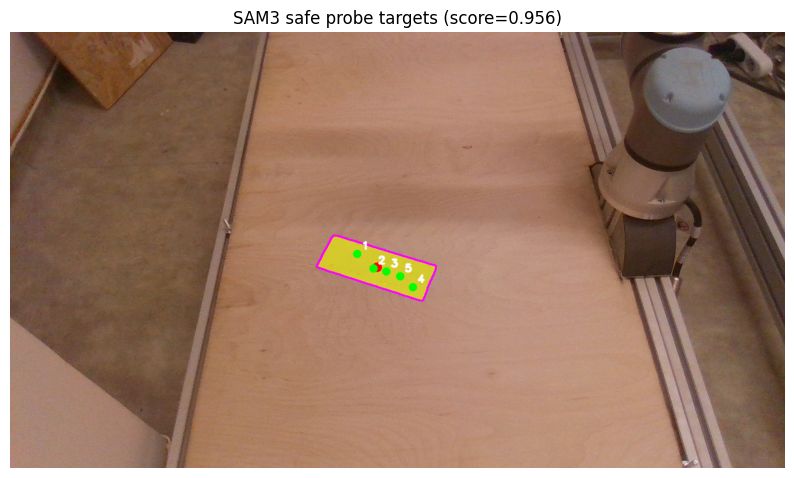

Mask selection info: {'mode': 'sam3_prompt', 'prompt': 'metal plate or sheet metal plate part in the middle of the MDF board', 'score': 0.9563727974891663, 'device': 'cuda', 'box_xyxy': [506.2149353027344, 335.70855712890625, 704.9423828125, 444.2310485839844]}
SAM3 prompt: metal plate or sheet metal plate part in the middle of the MDF board
SAM3 device: cuda
SAM3 best score: 0.9564
SAM3 best box (xyxy): [506.21 335.71 704.94 444.23]
Target centroid pixel: (606, 388)
Robust depth around centroid: 1.0430 m
Valid depth pixels in window: 100
Centroid robot target -> X=0.3814, Y=-0.2843, Z=-0.1195
Generated 5 safe probe targets after 19 attempts with EDGE_MARGIN_PX=15
Probe 1: pixel=(573, 366), edge=18.7px, depth=1.0590 m -> X=0.3848, Y=-0.3328, Z=-0.1165
Probe 2: pixel=(600, 390), edge=26.7px, depth=1.0410 m -> X=0.3880, Y=-0.2874, Z=-0.1189
Probe 3: pixel=(621, 395), edge=28.5px, depth=1.0330 m -> X=0.3788, Y=-0.2633, Z=-0.1165
Probe 4: pixel=(665, 421), edge=17.1px, depth=1.0110 m -> X=

In [16]:
color_image, depth_image = capture_aligned_rgbd_frame(pipeline, align)

target_mask, mask_info = select_target_mask(
    color_image,
    mode=MASK_MODE,
    prompt_text=SAM3_PROMPT_TEXT,
    sam3_segmenter=SAM3_SEGMENTER,
)

target_x, target_y, target_z, target_debug = get_robot_target_from_mask(
    target_mask,
    depth_image,
    depth_scale,
    K_matrix,
    T_base_to_cam,
    window_radius_px=WINDOW_RADIUS_PX,
)

probe_targets, plate_contour, probe_sampling_debug = generate_safe_probe_targets(
    target_mask,
    depth_image,
    depth_scale,
    K_matrix,
    T_base_to_cam,
    num_points=PROBE_POINT_COUNT,
    edge_margin_px=EDGE_MARGIN_PX,
    depth_window_radius_px=PROBE_DEPTH_WINDOW_RADIUS_PX,
    max_attempts=MAX_POINT_SAMPLING_ATTEMPTS,
    rng_seed=PROBE_RANDOM_SEED,
)

overlay_title = "Contour-safe probe targets"
if mask_info.get("mode", "").startswith("sam3") and mask_info.get("score") is not None:
    overlay_title = f"SAM3 safe probe targets (score={mask_info['score']:.3f})"

show_probe_targets_overlay(
    color_image,
    target_mask,
    probe_targets,
    contour=plate_contour,
    centroid_uv=target_debug["centroid_uv"],
    title=overlay_title,
)

print(f"Mask selection info: {mask_info}")
if mask_info.get("mode", "").startswith("sam3"):
    print(f"SAM3 prompt: {mask_info.get('prompt', SAM3_PROMPT_TEXT)}")
    if mask_info.get("device") is not None:
        print(f"SAM3 device: {mask_info['device']}")
    if mask_info.get("score") is not None:
        print(f"SAM3 best score: {mask_info['score']:.4f}")
    if mask_info.get("box_xyxy") is not None:
        print(f"SAM3 best box (xyxy): {np.round(mask_info['box_xyxy'], 2)}")
else:
    print(f"Manual ROI: {mask_info.get('roi')}")

print(f"Target centroid pixel: {target_debug['centroid_uv']}")
print(f"Robust depth around centroid: {target_debug['depth_m']:.4f} m")
print(f"Valid depth pixels in window: {target_debug['valid_depth_count']}")
print(f"Centroid robot target -> X={target_x:.4f}, Y={target_y:.4f}, Z={target_z:.4f}")
print(
    f"Generated {len(probe_targets)} safe probe targets after {probe_sampling_debug['attempt_count']} attempts "
    f"with EDGE_MARGIN_PX={probe_sampling_debug['edge_margin_px']}"
)
for target in probe_targets:
    base_x, base_y, base_z = target["base_point"]
    print(
        f"Probe {target['index']}: pixel={target['pixel_uv']}, edge={target['distance_to_edge_px']:.1f}px, "
        f"depth={target['depth_m']:.4f} m -> X={base_x:.4f}, Y={base_y:.4f}, Z={base_z:.4f}"
    )

In [17]:
rtde_r, rtde_c = connect_robot()

print("Initiating macro-to-micro handoff...")
print(f"Down orientation (rx, ry, rz): {DOWN_ORIENTATION}")
print(
    f"Robot will probe {len(probe_targets)} contour-safe points with SAFE_Z_MARGIN={SAFE_Z_MARGIN:.4f} m "
    f"and RETRACT_DIST={RETRACT_DIST:.4f} m"
)

try:
    plane_result = probe_surface_points(
        rtde_r,
        rtde_c,
        probe_targets,
        safe_z_margin=SAFE_Z_MARGIN,
        retract_dist=RETRACT_DIST,
        orientation=DOWN_ORIENTATION,
    )
except Exception:
    try:
        rtde_c.speedStop(1.0)
    except Exception:
        pass
    raise

a, b, c = plane_result["coeffs"]
normal = plane_result["normal"]

print("")
print("=== Plane extraction result ===")
for record in plane_result["contact_records"]:
    point = np.round(record["contact_point"], 4)
    print(
        f"P{record['index']}: pixel={record['pixel_uv']}, edge={record['distance_to_edge_px']:.1f}px -> "
        f"{point} (force={record['hit_force']:.3f} N)"
    )
print(f"z = {a:.6f}*x + {b:.6f}*y + {c:.6f}")
print(f"Normal vector: {np.round(normal, 6)}")
print(f"Plane offset d: {plane_result['plane_offset']:.6f}")
print(f"RMSE: {plane_result['rmse']:.6f} m")

Connecting to robot at 192.168.8.4...
Robot connection OK.
Initiating macro-to-micro handoff...
Down orientation (rx, ry, rz): [3.14159, 0.0, 0.0]
Robot will probe 5 contour-safe points with SAFE_Z_MARGIN=0.1500 m and RETRACT_DIST=0.0100 m
Starting contour-safe plane extraction...
Point 1/5 -> pixel=(573, 366), edge=18.7px, X=0.3848, Y=-0.3328, SAFE_Z=0.0335
  Contact at Z=0.0075 with force 1.574 N
Point 2/5 -> pixel=(600, 390), edge=26.7px, X=0.3880, Y=-0.2874, SAFE_Z=0.0311
  Contact at Z=0.0066 with force 1.857 N
Point 3/5 -> pixel=(621, 395), edge=28.5px, X=0.3788, Y=-0.2633, SAFE_Z=0.0335
  Contact at Z=0.0058 with force 1.834 N
Point 4/5 -> pixel=(665, 421), edge=17.1px, X=0.3729, Y=-0.2032, SAFE_Z=0.0332
  Contact at Z=0.0043 with force 1.639 N
Point 5/5 -> pixel=(644, 403), edge=27.5px, X=0.3705, Y=-0.2362, SAFE_Z=0.0340
  Contact at Z=0.0051 with force 1.565 N

=== Plane extraction result ===
P1: pixel=(573, 366), edge=18.7px -> [ 0.3849 -0.3328  0.0075] (force=1.574 N)
P2: pi

In [8]:
cleanup_connections(
    pipeline=globals().get("pipeline"),
    rtde_r=globals().get("rtde_r"),
    rtde_c=globals().get("rtde_c"),
    )

pipeline = None
rtde_r = None
rtde_c = None
print("Camera and robot connections closed.")

Camera and robot connections closed.
